In [94]:
words = open('../names.txt', 'r').read().splitlines()

In [65]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
occurences = {}
for word in words:
    value = ['.'] + list(word) + ['.']
    for ch1, ch2 in zip(value, value[1:]):
        data = (ch1,ch2)
        occurences[data] = occurences.get(data, 0) + 1

In [3]:
characters = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(characters)}
stoi['.'] = 0
stoi
itos = {i:s for s,i in stoi.items()}

In [7]:
import torch

In [44]:
## Creating data set which will have a 3 characters and using that we will try to predict next character so only thing changed from last make more implementation is that 
## no we will store three character index in xs and one in ys which needs to be predicted
block_size = 3
xs = []
ys = []
for word in words:
    val = [0] * block_size
    for ch in word + '.':
        xs.append(val)
        ys.append(stoi.get(ch))
        val = val[1:] + [stoi.get(ch)]
# print(f'{xs} -> {ys}')


In [45]:
X = torch.tensor(xs)
Y = torch.tensor(ys)

In [46]:
## lets create embedding matrix instead of one hot encoding as becuase this helps understand the relationship between characters and also they are much more expressive
## and scalable.
lookUpMat = torch.randn((27,2))
lookUpMat

tensor([[-2.4232e-03, -6.4517e-01],
        [-5.4003e-01,  1.4327e+00],
        [ 4.6052e-01, -1.5057e+00],
        [-1.3948e-01,  1.5733e+00],
        [-1.4271e+00,  8.0663e-01],
        [ 1.9499e-01,  1.0349e+00],
        [ 9.7476e-01,  1.3822e+00],
        [ 9.8935e-01,  7.3168e-01],
        [-3.5925e-01, -1.4670e+00],
        [ 2.7902e+00,  1.4149e-01],
        [-2.2062e-01,  3.2945e-01],
        [-6.2811e-01,  7.1374e-01],
        [ 1.1767e+00, -1.5457e-01],
        [ 9.5772e-01, -2.8862e-01],
        [ 4.3812e-01,  3.5759e-01],
        [-1.3134e+00, -3.4754e-01],
        [ 4.1105e-02, -1.6738e+00],
        [ 9.9185e-01, -2.6364e-01],
        [-1.4905e-01, -1.1508e+00],
        [-4.2155e-01, -1.0837e+00],
        [ 5.2731e-01, -8.5000e-01],
        [ 5.4151e-02,  5.6894e-01],
        [-9.2980e-02, -2.4848e-01],
        [-5.8259e-03, -6.7909e-01],
        [-1.0374e-01, -3.2464e+00],
        [-8.0506e-01, -7.3241e-01],
        [-6.5977e-01,  4.5707e-01]])

In [47]:
emb = lookUpMat[X]

In [23]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)
W2 = torch.randn(100,27)
b2 = torch.randn(27)


In [28]:
h = torch.tanh(emb.view(-1,6) @ W1 + b1) ## activation function
logits = h @ W2 + b2
## forward pass

In [ ]:
norm = logits.exp()
pred = norm / norm.sum(dim=1, keepdim=True)
pred

tensor([[2.9795e-12, 2.3349e-09, 7.0381e-05, 5.3471e-05, 1.2537e-09, 4.0847e-05,
         1.5728e-13, 3.8514e-02, 6.6302e-13, 7.7971e-05, 7.8784e-05, 5.5963e-05,
         9.6616e-13, 3.5796e-13, 3.9972e-08, 2.8042e-02, 1.5493e-07, 3.7753e-01,
         8.8009e-11, 7.4489e-09, 4.1060e-14, 1.7980e-03, 2.2350e-08, 1.7024e-12,
         4.9019e-13, 5.5373e-01, 4.2178e-06],
        [5.8191e-14, 7.0704e-11, 5.6112e-01, 5.8236e-05, 3.9091e-09, 4.0824e-08,
         3.5452e-09, 1.0785e-02, 8.0886e-17, 1.4719e-01, 1.0463e-04, 6.3611e-07,
         1.0936e-07, 1.0042e-09, 1.5767e-10, 2.4301e-03, 7.4594e-08, 1.2726e-04,
         3.1530e-10, 1.4292e-11, 3.7199e-10, 1.5794e-05, 9.3689e-09, 1.2352e-13,
         5.8453e-11, 2.7772e-01, 4.4041e-04],
        [3.4780e-15, 1.9435e-09, 7.6907e-01, 4.3031e-08, 1.7093e-09, 7.1759e-11,
         4.1023e-11, 1.3682e-04, 4.9310e-15, 2.2787e-01, 2.4117e-03, 7.9375e-06,
         1.8874e-09, 1.5389e-13, 2.9125e-07, 4.7380e-04, 2.8550e-11, 1.1749e-08,
         3.5059e-

In [ ]:
loss = -pred[torch.arange(len(X)), Y].log().mean() # loss calculation
loss

tensor(15.7781)

In [70]:
# structured code
g = torch.Generator().manual_seed(2147483647)
lookUpMat = torch.randn((27,2), requires_grad=True)
emb = lookUpMat[X]
W1 = torch.randn((6,100), requires_grad=True)
b1 = torch.randn((100), requires_grad=True)
W2 = torch.randn((100,27), requires_grad=True)
b2 = torch.randn((27),requires_grad=True)
params = [lookUpMat, W1, b1, W2, b2]

In [71]:
sum(p.nelement() for p in params)

3481

In [72]:
for p in params:
    p.grad = None

In [73]:
## Finding suitable learning rate
lr = torch.linspace(-3,0,1000)
lr = 10 ** lr
lr

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [74]:
## Verify the better learing rate
lossi = []
lri = []

In [83]:
## starting to train the model
for i in range(1001):
    ## forward pass
    # ----- batch processing
    xi = torch.randint(0, X.shape[0],(32,))
    Xb = X[xi]
    Yb = Y[xi]
    # ----- batch processing
    emb = lookUpMat[Xb]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) ## activation function
    logits = h @ W2 + b2
    # -----------------
    norm = logits.exp()
    pred = norm / norm.sum(dim=1, keepdim=True)
    # ----------------- (SoftMax)
    loss = -pred[torch.arange(len(Xb)), Yb].log().mean() # loss calculation
    
    lossi.append(loss.item())
    if i%100 == 0:
        print(loss)
    # gred zero
    for p in params:
        p.grad = None
    
    # backpropagartion
    loss.backward()
    lr = 0.05
    # updating weights
    for p in params:
        p.data += -lr * p.grad
    # lri.append(lr[i].item())

tensor(2.1510, grad_fn=<NegBackward0>)
tensor(2.2486, grad_fn=<NegBackward0>)
tensor(2.7863, grad_fn=<NegBackward0>)
tensor(2.5105, grad_fn=<NegBackward0>)
tensor(2.4733, grad_fn=<NegBackward0>)
tensor(2.3372, grad_fn=<NegBackward0>)
tensor(2.4350, grad_fn=<NegBackward0>)
tensor(2.1807, grad_fn=<NegBackward0>)
tensor(2.6630, grad_fn=<NegBackward0>)
tensor(2.0666, grad_fn=<NegBackward0>)
tensor(2.4722, grad_fn=<NegBackward0>)


In [67]:
print(lossi)
print(lri)

[19.118026733398438, 18.684659957885742, 18.915977478027344, 15.33009147644043, 16.91610336303711, 16.279062271118164, 14.767964363098145, 17.524524688720703, 14.937957763671875, 19.264968872070312, 16.385663986206055, 20.10769271850586, 17.647735595703125, 15.317766189575195, 18.889984130859375, 18.023380279541016, 16.15896987915039, 14.792802810668945, 16.162992477416992, 19.176311492919922, 15.130772590637207, 17.68383026123047, 17.386436462402344, 19.754291534423828, 20.25020408630371, 16.508255004882812, 18.001262664794922, 16.437868118286133, 14.315118789672852, 15.900259017944336, 16.274547576904297, 19.59624481201172, 16.6488037109375, 17.072093963623047, 16.821678161621094, 17.596641540527344, 14.020791053771973, 16.03055191040039, 19.010026931762695, 16.18548011779785, 15.103361129760742, 15.566768646240234, 18.7237548828125, 16.46060562133789, 16.20508575439453, 15.66534423828125, 15.868474960327148, 20.338651657104492, 16.808713912963867, 16.31725311279297, 15.4820632934570

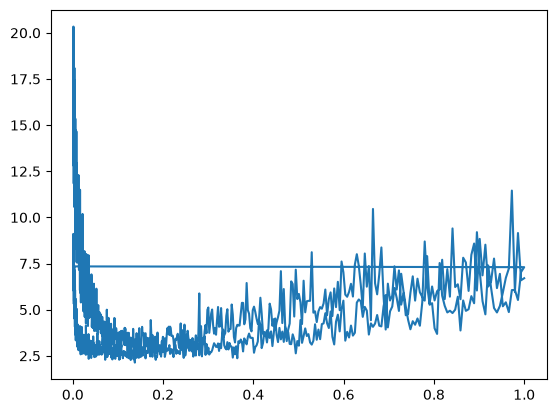

In [68]:
## plot the loss and lr
plt.plot(lri, lossi)

In [98]:
## Let create different datasets for training, testing , dev/validation
import random

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

trainingDataset = words[:n1]
validationDataset = words[n1:n2]
testingDataSet = words[n2:]


In [100]:
def build_dataset(words):
    block_size = 3
    xs = []
    ys = []
    for word in words:
        val = [0] * block_size
        for ch in word + '.':
            xs.append(val)
            ys.append(stoi.get(ch))
            val = val[1:] + [stoi.get(ch)]
    return torch.tensor(xs), torch.tensor(ys)


In [101]:
## different datasets
Xtr, Ytr = build_dataset(trainingDataset)
Xdev, Ydev = build_dataset(validationDataset)
Xtest, Ytest = build_dataset(testingDataSet)


In [152]:
## ----- Post Data Segragation Between Training, Test and Dev/Validation ----- ##

g = torch.Generator().manual_seed(2147483647)
lookUpMat = torch.randn((27,20), requires_grad=True)
W1 = torch.randn((60,400), requires_grad=True)
b1 = torch.randn((400), requires_grad=True)
W2 = torch.randn((400,27), requires_grad=True)
b2 = torch.randn((27),requires_grad=True)
params = [lookUpMat, W1, b1, W2, b2]
paramSum = sum(p.nelement() for p in params)
paramSum

35767

In [180]:
## starting to train the model (With the training dataset)
for i in range(20000):
    ## forward pass
    # ----- batch processing
    xi = torch.randint(0, Xtr.shape[0],(32,))
    Xb = Xtr[xi]
    Yb = Ytr[xi]
    # ----- batch processing
    emb = lookUpMat[Xb]
    h = torch.tanh(emb.view(-1,60) @ W1 + b1) ## activation function
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)
    
    lossi.append(loss.item())
    if i%2000 == 0:
        print(loss)
    # gred zero
    for p in params:
        p.grad = None
    
    # backpropagartion
    loss.backward()
    lr = 0.03
    # updating weights
    for p in params:
        p.data += -lr * p.grad
    # lri.append(lr[i].item())

tensor(1.9734, grad_fn=<NllLossBackward0>)
tensor(2.3505, grad_fn=<NllLossBackward0>)
tensor(2.0674, grad_fn=<NllLossBackward0>)
tensor(2.0892, grad_fn=<NllLossBackward0>)
tensor(2.0440, grad_fn=<NllLossBackward0>)
tensor(2.3210, grad_fn=<NllLossBackward0>)
tensor(2.2080, grad_fn=<NllLossBackward0>)
tensor(2.2788, grad_fn=<NllLossBackward0>)
tensor(1.9524, grad_fn=<NllLossBackward0>)
tensor(2.0565, grad_fn=<NllLossBackward0>)


In [181]:
## --- validating training
emb = lookUpMat[Xdev]
h = torch.tanh(emb.view(-1,60) @ W1 + b1) ## activation function
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2554, grad_fn=<NllLossBackward0>)

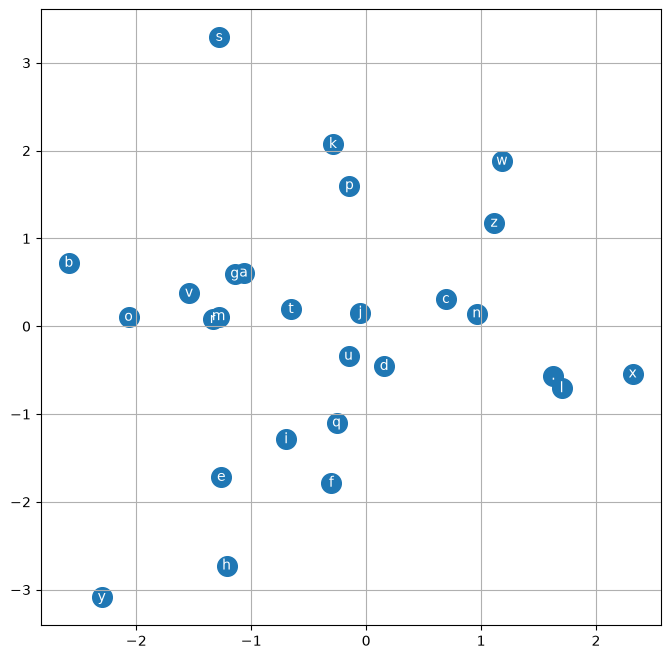

In [182]:
plt.figure(figsize=(8,8))
plt.scatter(lookUpMat[:,0].data, lookUpMat[:,1].data, s=200)
for i in range(lookUpMat.shape[0]):
    plt.text(lookUpMat[i,0].item(), lookUpMat[i,1].item(), itos[i], ha="center", va="center", color='white')
    plt.grid('minor')

In [ ]:
## Produce Names
g = torch.Generator().manual_seed(2147483647)
for _ in range(20):
    ix = [0] * block_size
    word = ""
    while True:
        emb = lookUpMat[ix]
        h = torch.tanh(emb.view(-1,60) @ W1 + b1) ## activation function
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        predIx = torch.multinomial(probs, num_samples=1, replacement=True, generator = g).item()
        ix = ix[1:] + [predIx]
        word += itos.get(predIx)
        if predIx == 0:
            break
    print(word)
    